In [12]:
import pandas as pd

# Create a dummy DataFrame with similar structure
data = {
    'name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve', 'Frank', 'Grace', 'Heidi', 'Ivan', 'Judy'],
    'math': [88, 42, 75, 95, 38, 60, 82, 55, 70, 90],
    'science': [92, 55, 70, 98, 42, 65, 85, 60, 72, 93],
    'english': [76, 48, 80, 91, 50, 72, 78, 65, 75, 88],
    'history': [80, 50, 68, 89, 45, 58, 80, 50, 70, 91],
    'pe': [95, 60, 88, 97, 55, 70, 90, 70, 80, 94],
    'attendance_pct': [92, 65, 85, 98, 58, 70, 88, 75, 80, 95],
    'study_hours_per_day': [4.5, 1.2, 3.0, 6.0, 0.8, 2.5, 4.0, 1.5, 3.5, 5.0],
    'passed': [1, 0, 1, 1, 0, 1, 1, 0, 1, 1]
}
df_dummy = pd.DataFrame(data)

# Save the dummy DataFrame to 'student.csv'
df_dummy.to_csv('student.csv', index=False)

print("Created 'student.csv' with dummy data.")
print(df_dummy.head())

Created 'student.csv' with dummy data.
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [10]:
# =========================================================
# TASK 1 — DATA EXPLORATION WITH PANDAS
# =========================================================

import pandas as pd

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("student.csv")

# -------------------------------
# 1. Display first 5 rows
# -------------------------------
print("\nFirst 5 rows:\n")
print(df.head())

# -------------------------------
# 2. Shape and data types
# -------------------------------
print("\nDataset Shape (rows, columns):")
print(df.shape)

print("\nData Types:\n")
print(df.dtypes)

# -------------------------------
# 3. Summary statistics
# -------------------------------
print("\nSummary Statistics:\n")
print(df.describe())

# -------------------------------
# 4. Count of pass vs fail
# -------------------------------
print("\nPass/Fail Count:\n")
print(df["passed"].value_counts())

# -------------------------------
# 5. Average score per subject
# -------------------------------

subject_cols = ["math", "science", "english", "history", "pe"]

# For passed students
passed_avg = df[df["passed"] == 1][subject_cols].mean()

# For failed students
failed_avg = df[df["passed"] == 0][subject_cols].mean()

print("\nAverage Scores (Passed Students):\n")
print(passed_avg)

print("\nAverage Scores (Failed Students):\n")
print(failed_avg)

# -------------------------------
# 6. Student with highest overall average
# -------------------------------

# Create a new column for average marks
df["avg_score"] = df[subject_cols].mean(axis=1)

# Find student with max average
top_student = df.loc[df["avg_score"].idxmax()]

print("\nTop Performing Student:\n")
print("Name:", top_student["name"])
print("Average Score:", round(top_student["avg_score"], 2))


First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Dataset Shape (rows, columns):
(10, 9)

Data Types:

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:

            ma

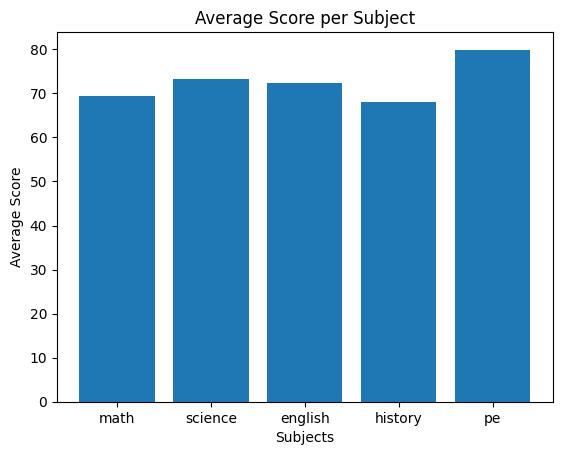

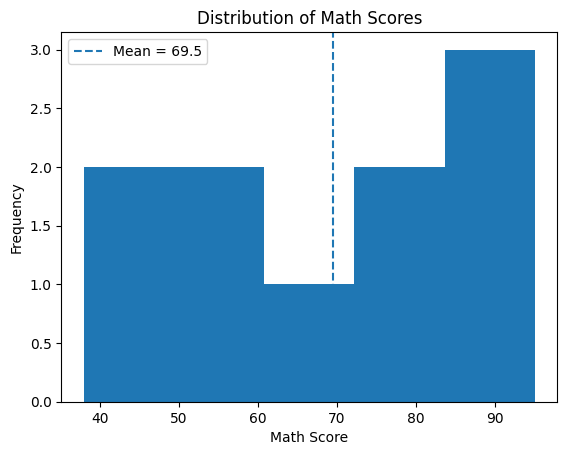

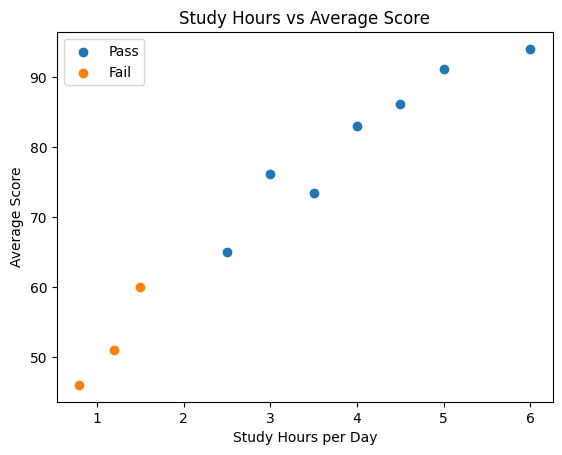

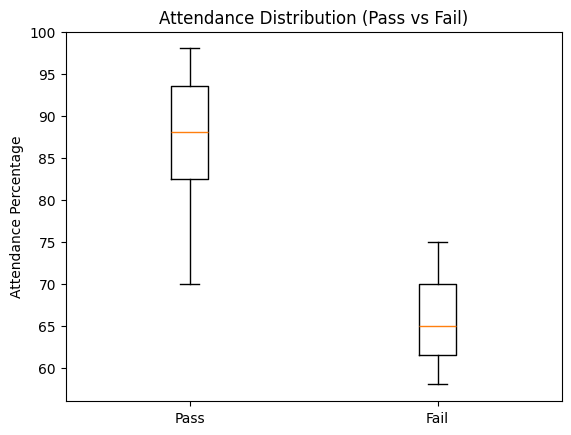

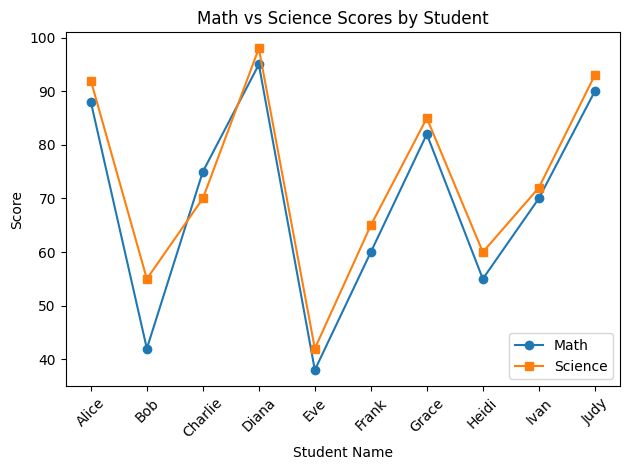

In [14]:
# =========================================================
# TASK 2 — DATA VISUALIZATION WITH MATPLOTLIB
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("student.csv")

# Add average score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1);

# -------------------------------------------------
# 1. BAR CHART — Average score per subject
# -------------------------------------------------

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(subject_cols, avg_scores)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()


# -------------------------------------------------
# 2. HISTOGRAM — Math score distribution
# -------------------------------------------------

plt.figure()
plt.hist(df['math'], bins=5)

# Mean line
mean_math = df['math'].mean()
plt.axvline(mean_math, linestyle='--', label=f"Mean = {round(mean_math,2)}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()

plt.savefig("plot2_hist.png")
plt.show()


# -------------------------------------------------
# 3. SCATTER PLOT — Study hours vs Avg score
# -------------------------------------------------

plt.figure()

# Separate pass/fail groups
passed = df[df['passed'] == 1]
failed = df[df['passed'] == 0]

plt.scatter(passed['study_hours_per_day'], passed['avg_score'], label="Pass")
plt.scatter(failed['study_hours_per_day'], failed['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()


# -------------------------------------------------
# 4. BOX PLOT — Attendance comparison
# -------------------------------------------------

pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_att, fail_att], tick_labels=["Pass", "Fail"])

plt.title("Attendance Distribution (Pass vs Fail)")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()


# -------------------------------------------------
# 5. LINE PLOT — Math vs Science scores
# -------------------------------------------------

plt.figure()

names = df['name']

plt.plot(names, df['math'], marker='o', label="Math")
plt.plot(names, df['science'], marker='s', label="Science")

plt.title("Math vs Science Scores by Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()  # prevent overlap

plt.savefig("plot5_line.png")
plt.show()

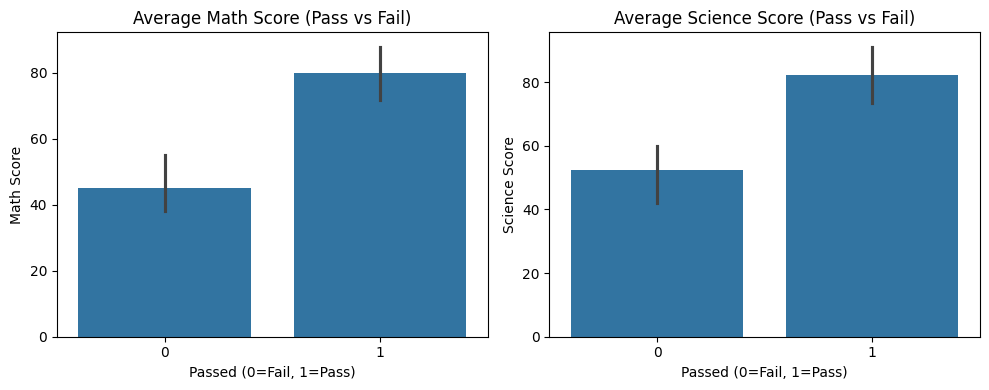

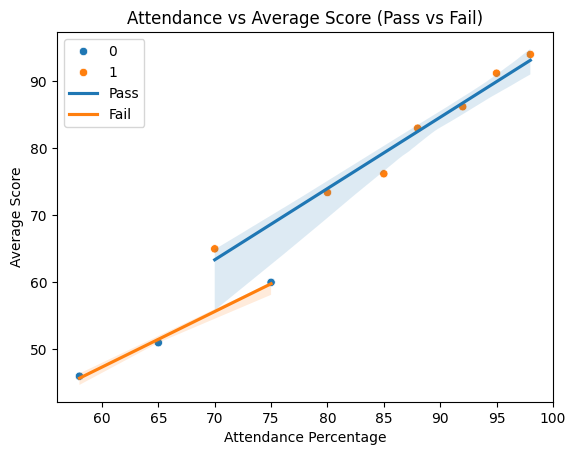

In [16]:
# =========================================================
# TASK 3 — DATA VISUALIZATION WITH SEABORN
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("student.csv")

# Create avg_score column (needed for scatter plot)
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# -------------------------------------------------
# 1. BAR PLOT — Avg Math & Science by Pass/Fail
# -------------------------------------------------

plt.figure(figsize=(10, 4))

# Subplot 1: Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2: Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# -------------------------------------------------
# 2. SCATTER + REGRESSION — Attendance vs Avg Score
# -------------------------------------------------

plt.figure()

# Scatter plot (with hue)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines for each group
sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Pass')

sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            scatter=False, label='Fail')

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# -------------------------------------------------
# COMPARISON (IMPORTANT FOR MARKS)
# -------------------------------------------------

# Seaborn was easier to use for statistical plots like barplots and regression lines,
# as it automatically calculates averages and trends.
# Compared to Matplotlib, Seaborn required less manual coding for styling and grouping,
# but Matplotlib gave more control for custom layouts and fine adjustments.


Training Accuracy: 100.0 %
Test Accuracy: 100.0 %

Test Predictions:

Ivan: Actual=1, Predicted=1 -> ✅ Correct
Bob: Actual=0, Predicted=0 -> ✅ Correct

Feature Importance (sorted):

english: 0.4984
study_hours_per_day: 0.4512
history: 0.4329
math: 0.384
science: 0.3405
pe: 0.3136
attendance_pct: 0.1323


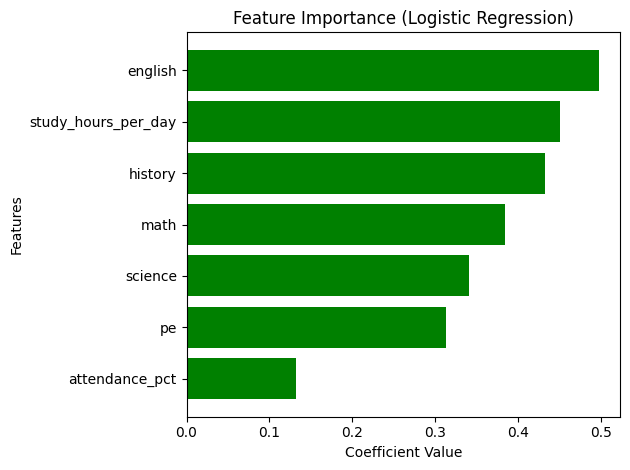


New Student Prediction:
Result: Pass
Probability (Fail, Pass): [0.17116301 0.82883699]


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# -------------------------------
# Load dataset
# -------------------------------
df = pd.read_csv("student.csv")

# -------------------------------
# Step 1 — Prepare Data
# -------------------------------

# Features (excluding 'name' and 'passed')
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]
y = df['passed']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# -------------------------------
# Step 2 — Train Model
# -------------------------------

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Training accuracy
train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)

print("\nTraining Accuracy:", round(train_acc * 100, 2), "%")

# -------------------------------
# Step 3 — Evaluate Model
# -------------------------------

test_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

print("Test Accuracy:", round(test_acc * 100, 2), "%")

print("\nTest Predictions:\n")

# Get names using original index
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, test_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} -> {status}")

# -------------------------------
# Step 4 — Feature Importance
# -------------------------------

coefficients = model.coef_[0]

# Pair feature with coefficient
feature_importance = list(zip(feature_cols, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance (sorted):\n")
for feature, coef in feature_importance:
    print(f"{feature}: {round(coef, 4)}")

# Plot coefficients
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

# Color based on sign
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()
plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()  # highest on top

plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()

# -------------------------------
# Step 5 — Predict New Student
# -------------------------------

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
# Convert new_student to a DataFrame with feature names
new_student_data = pd.DataFrame(new_student, columns=feature_cols)

# Scale using same scaler
new_scaled = scaler.transform(new_student_data)

prediction = model.predict(new_scaled)[0]
probability = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Result:", result)
print("Probability (Fail, Pass):", probability)